In [ ]:
EXPERIMENT 8

In [ ]:
Scenario 1:

Dataset: https://www.kaggle.com/datasets/heeraldedhia/groceries-dataset

In [ ]:
Objective:

To identify frequent itemsets and generate association rules from transactional grocery data using the Apriori algorithm.

In [ ]:
Target Variable: Association rules (frequent item relationships)

Input Features: Transaction ID (Member_number), Items purchased (itemDescription)


K.Nivedha(24BAD082)

EXPERIMENT 8

SCENARIO 1: ASSOCIATION RULE MINING (APRIORI)

Dataset Preview:
   Member_number        Date   itemDescription
0           1808  21-07-2015    tropical fruit
1           2552  05-01-2015        whole milk
2           2300  19-09-2015         pip fruit
3           1187  12-12-2015  other vegetables
4           3037  01-02-2015        whole milk

Columns: Index(['Member_number', 'Date', 'itemDescription'], dtype='object')

Basket Shape: (3898, 167)

Frequent Itemsets:
    support         itemsets
0  0.078502       (UHT-milk)
1  0.031042  (baking powder)
2  0.119548           (beef)
3  0.079785        (berries)
4  0.062083      (beverages)
5  0.158799   (bottled beer)
6  0.213699  (bottled water)
7  0.135967    (brown bread)
8  0.126475         (butter)
9  0.064905    (butter milk)

Association Rules:
                                 antecedents                     consequents  \
808                  (yogurt, bottled water)  (whole milk, other vegetable

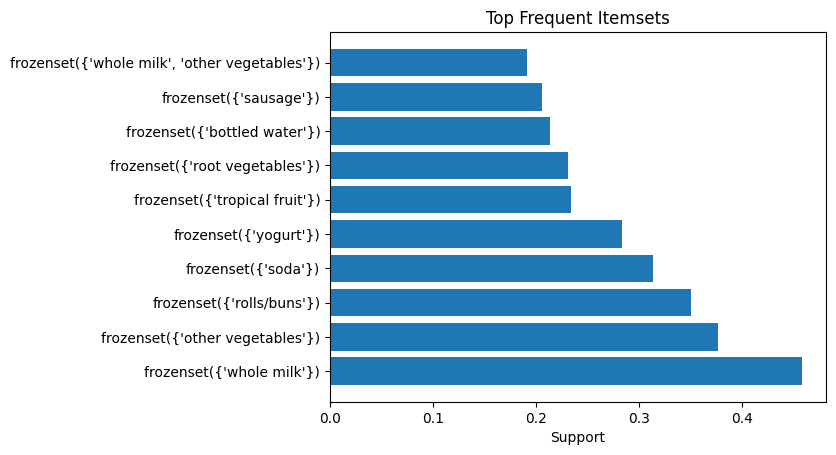

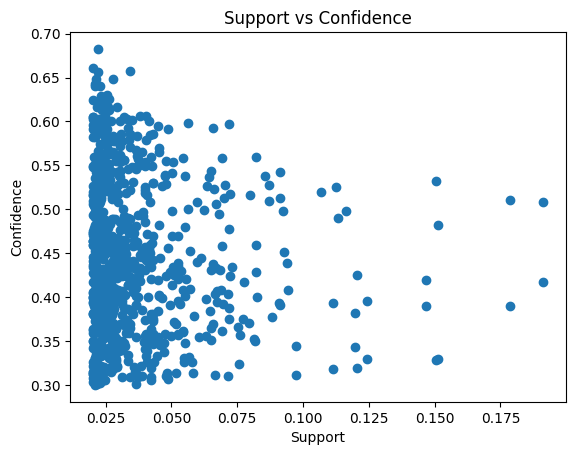

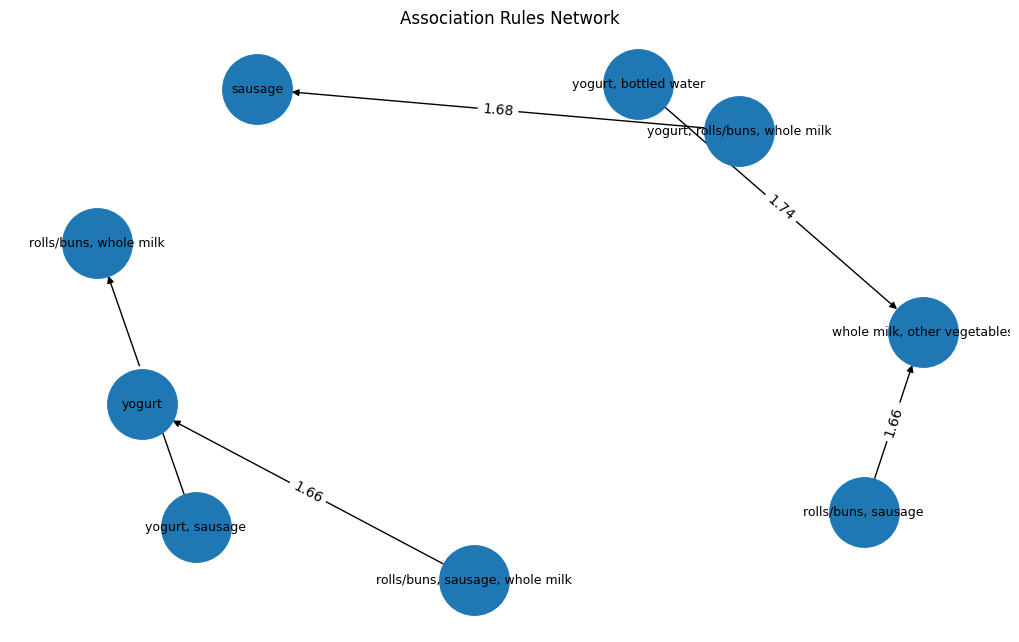

In [1]:
print("\nK.Nivedha(24BAD082)")
print("\nEXPERIMENT 8")
print("\nSCENARIO 1: ASSOCIATION RULE MINING (APRIORI)\n")

import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from mlxtend.frequent_patterns import apriori, association_rules

#Load Dataset
df = pd.read_csv(r"C:\Users\nived\OneDrive\Documents\Groceries_dataset.csv")

print("Dataset Preview:")
print(df.head())

print("\nColumns:", df.columns)

#Data Preprocessing
#Convert transactional data into one-hot encoding

basket = df.groupby(['Member_number', 'itemDescription'])['itemDescription'] \
           .count().unstack().fillna(0)

#Convert to boolean (0/1)
basket = basket > 0

print("\nBasket Shape:", basket.shape)

#Generate Frequent Itemsets
frequent_itemsets = apriori(basket, min_support=0.02, use_colnames=True)

print("\nFrequent Itemsets:")
print(frequent_itemsets.head(10))

#Generate Association Rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)

#Sort by lift
rules = rules.sort_values(by='lift', ascending=False)

print("\nAssociation Rules:")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

#Strong Rules
strong_rules = rules[(rules['confidence'] > 0.5) & (rules['lift'] > 1)]

print("\nStrong Rules:")
print(strong_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

#Support Threshold Analysis
print("\nSupport Threshold Analysis:")
supports = [0.01, 0.02, 0.05]

for s in supports:
    fi = apriori(basket, min_support=s, use_colnames=True)
    print(f"Support = {s} → Itemsets = {len(fi)}")

#Confidence Comparison
low_conf = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.2)
high_conf = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)

print("\nConfidence Comparison:")
print("Low confidence rules:", len(low_conf))
print("High confidence rules:", len(high_conf))

#Visualization - Bar Chart
top_items = frequent_itemsets.nlargest(10, 'support')

plt.figure()
plt.barh(range(len(top_items)), top_items['support'])
plt.yticks(range(len(top_items)), top_items['itemsets'].astype(str))
plt.xlabel("Support")
plt.title("Top Frequent Itemsets")
plt.show()

#Visualization - Scatter Plot
plt.figure()
plt.scatter(rules['support'], rules['confidence'])
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence")
plt.show()

#Visualization 
#Take top 5 rules (to avoid clutter)
top_rules = rules.head(5)

G = nx.DiGraph()

#Add edges with clean labels
for _, row in top_rules.iterrows():
    antecedent = ', '.join(list(row['antecedents']))
    consequent = ', '.join(list(row['consequents']))
    G.add_edge(antecedent, consequent, weight=row['lift'])

#Better layout for spacing
plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G, k=2, seed=42)

#Draw nodes and edges
nx.draw(
    G, pos,
    with_labels=True,
    node_size=2500,
    font_size=9
)

#Show lift values on edges
edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Association Rules Network")
plt.show()

In [ ]:
1.Imported required Python libraries.
2.Loaded the grocery dataset.
3.Performed data preprocessing and converted data into one-hot encoding format.
4.Created a transaction-item matrix using grouping.
5.Applied Apriori algorithm to generate frequent itemsets.
6.Set minimum support threshold.
7.Generated association rules using confidence metric.
8.Filtered rules using confidence and lift.
9.Identified strong association rules.
10.Compared results for different support and confidence values.
11.Evaluated using:
    Support
    Confidence
    Lift
12.Visualized:
    Bar chart 
    Scatter plot 
    Network graph

In [ ]:
Output:

-Frequent itemsets were successfully identified based on support.
-Association rules revealed relationships between items.
-Lift values indicated strength of item associations.
-Strong rules helped in understanding customer buying patterns.
-Visualization clearly showed item relationships and trends.

In [ ]:
Scenario 2:

Dataset: https://www.kaggle.com/datasets/heeraldedhia/groceries-dataset

In [ ]:
Objective:

To reduce high-dimensional grocery transaction data into lower dimensions while preserving maximum variance using Principal Component Analysis (PCA).k

In [ ]:
Target Variable: Principal components (reduced feature set)

Input Features: Numerical representation of items (one-hot encoded item matrix)


K.Nivedha(24BAD082)

EXPERIMENT 8

SCENARIO 2: PCA (DIMENSIONALITY REDUCTION)

Dataset Preview:
   Member_number        Date   itemDescription
0           1808  21-07-2015    tropical fruit
1           2552  05-01-2015        whole milk
2           2300  19-09-2015         pip fruit
3           1187  12-12-2015  other vegetables
4           3037  01-02-2015        whole milk

Shape after encoding: (3898, 167)

Explained Variance Ratio:
[0.01592942 0.00875797 0.00869744 0.00868125 0.00857885 0.00850037
 0.00838747 0.00836396 0.00825556 0.00823771]

Cumulative Variance:
[0.01592942 0.02468739 0.03338483 0.04206608 0.05064492 0.05914529
 0.06753277 0.07589673 0.08415229 0.09239   ]


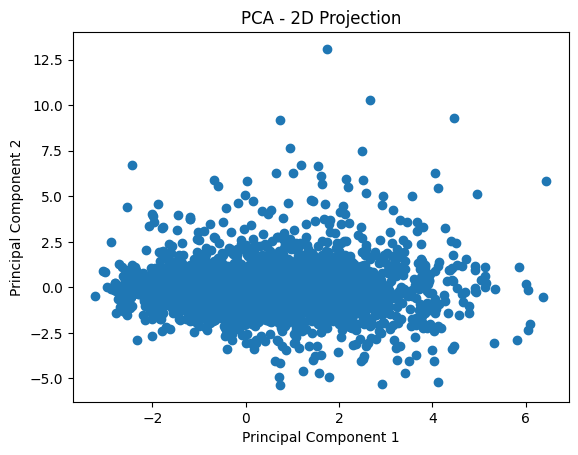

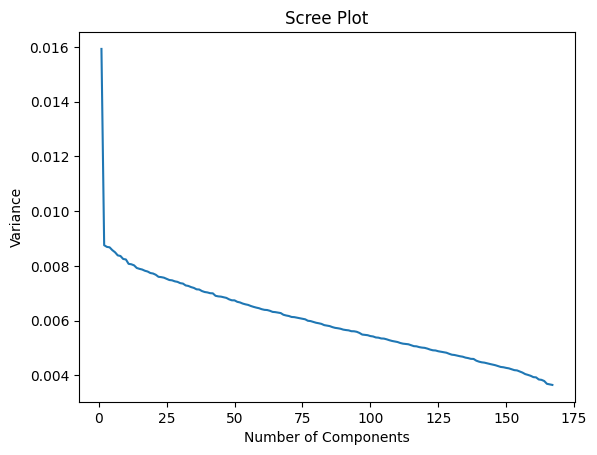

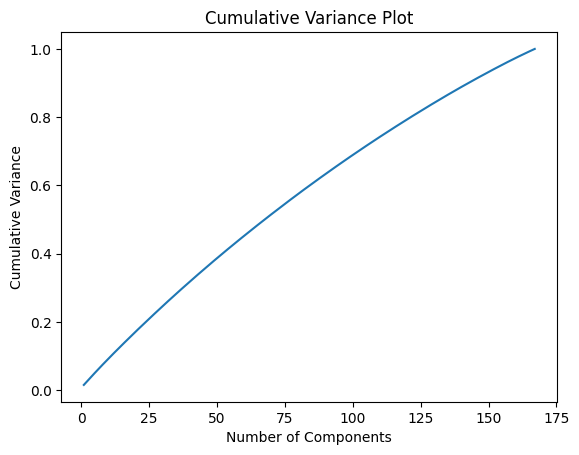

In [2]:
print("\nK.Nivedha(24BAD082)")
print("\nEXPERIMENT 8")
print("\nSCENARIO 2: PCA (DIMENSIONALITY REDUCTION)\n")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#Load Dataset
df = pd.read_csv(r"C:\Users\nived\OneDrive\Documents\Groceries_dataset.csv")

print("Dataset Preview:")
print(df.head())

#Convert to One-Hot Encoding
basket = df.groupby(['Member_number', 'itemDescription'])['itemDescription'] \
           .count().unstack().fillna(0)

#Convert to binary (0/1)
basket = basket > 0

print("\nShape after encoding:", basket.shape)

#Standardize Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(basket)

#Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

#Explained Variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("\nExplained Variance Ratio:")
print(explained_variance[:10])

print("\nCumulative Variance:")
print(cumulative_variance[:10])

#Reduce to 2 Components
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)

#2D Visualization
plt.figure()
plt.scatter(X_pca2[:, 0], X_pca2[:, 1])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - 2D Projection")
plt.show()

#Scree Plot
plt.figure()
plt.plot(range(1, len(explained_variance)+1), explained_variance)
plt.xlabel("Number of Components")
plt.ylabel("Variance")
plt.title("Scree Plot")
plt.show()

#Cumulative Variance Plot
plt.figure()
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.title("Cumulative Variance Plot")
plt.show()

In [ ]:
1.Imported required Python libraries.
2.Loaded the grocery dataset.
3.Converted categorical transaction data into numerical one-hot encoding.
4.Standardized the dataset using scaling techniques.
5.Applied PCA to transform data into principal components.
6.Computed explained variance ratio.
7.Selected optimal number of components.
8.Reduced dimensions to 2 components.
9.Analyzed variance captured by each component.
10.Evaluated using:
    Explained Variance Ratio
    Cumulative Variance
11.Visualized:
    Scree plot (variance vs components)
    2D/3D scatter plot of principal components
    Cumulative variance graph



In [ ]:
Output:

-PCA successfully reduced high-dimensional data into fewer components.
-Maximum variance was preserved in the first few components.
-Dimensionality reduction improved data visualization.
-Scree plot helped identify optimal number of components.
-Reduced data provided a simplified representation of original dataset.